<a href="https://colab.research.google.com/github/icosahedron31/Walmart-Sales/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle --version

Kaggle CLI 2.0.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting


You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [5]:
! mkdir ~/.kaggle
!cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [6]:
! chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

100% 2.70M/2.70M [00:00<00:00, 157MB/s]



In [8]:
! unzip walmart-recruiting-store-sales-forecasting

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [9]:
! unzip features.csv.zip
! unzip test.csv.zip
! unzip train.csv.zip


Archive:  features.csv.zip
  inflating: features.csv            
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  train.csv.zip
  inflating: train.csv               


In [10]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from sklearn.model_selection import train_test_split
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [11]:
df_sales = pd.read_csv("train.csv")
df_stores = pd.read_csv("stores.csv")
df_features = pd.read_csv("features.csv")

**Analyzing Sales**

In [12]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [13]:
print("Shape:", df_sales.shape)
print(df_sales[["Weekly_Sales"]].describe())
print("\nNegative sales:", (df_sales["Weekly_Sales"] < 0).sum())
print("Zero sales:", (df_sales["Weekly_Sales"] == 0).sum())
print("Min/Max:", df_sales["Weekly_Sales"].min(), df_sales["Weekly_Sales"].max())

Shape: (421570, 5)
        Weekly_Sales
count  421570.000000
mean    15981.258123
std     22711.183519
min     -4988.940000
25%      2079.650000
50%      7612.030000
75%     20205.852500
max    693099.360000

Negative sales: 1285
Zero sales: 73
Min/Max: -4988.94 693099.36


In [29]:
df_sales["Date"] = pd.to_datetime(df_sales["Date"])


Sales and Log1p(Sales)

Text(0.5, 1.0, 'log1p (skew=-1.29, kurt=1.94)')

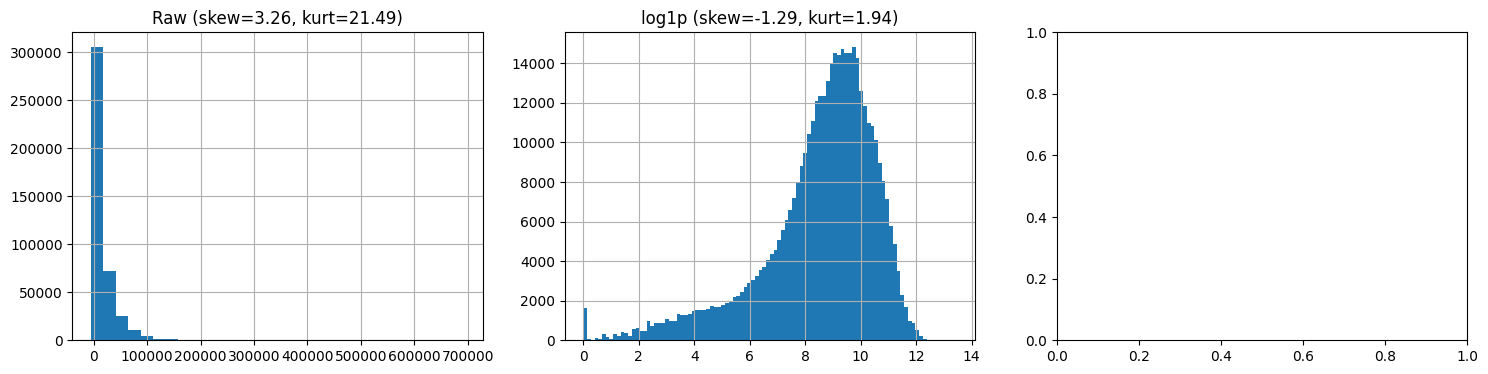

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df_sales["Weekly_Sales"].hist(bins=30, ax=axes[0])
axes[0].set_title(f"Raw (skew={df_sales['Weekly_Sales'].skew():.2f}, "
                   f"kurt={df_sales['Weekly_Sales'].kurt():.2f})")

log1p_sales = np.log1p(df_sales["Weekly_Sales"].clip(lower=0))
log1p_sales.hist(bins=100, ax=axes[1])
axes[1].set_title(f"log1p (skew={log1p_sales.skew():.2f}, "
                   f"kurt={log1p_sales.kurt():.2f})")

Text(0.5, 1.0, 'Mean-variance relationship (Store x Dept)')

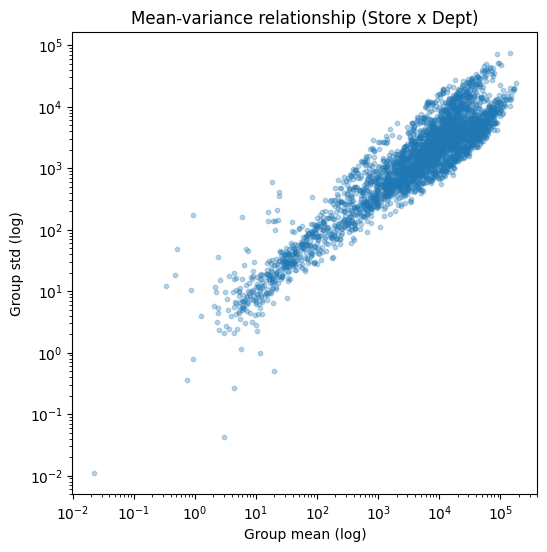

In [16]:
grp_stats = (
    df_sales.groupby(["Store", "Dept"])["Weekly_Sales"]
    .agg(["mean", "std", "count"])
    .dropna()
)
grp_stats = grp_stats[grp_stats["mean"] > 0]  # log-log plot needs positive values

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(grp_stats["mean"], grp_stats["std"], alpha=0.3, s=10)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Group mean (log)"); ax.set_ylabel("Group std (log)")
ax.set_title("Mean-variance relationship (Store x Dept)")

Total Sales

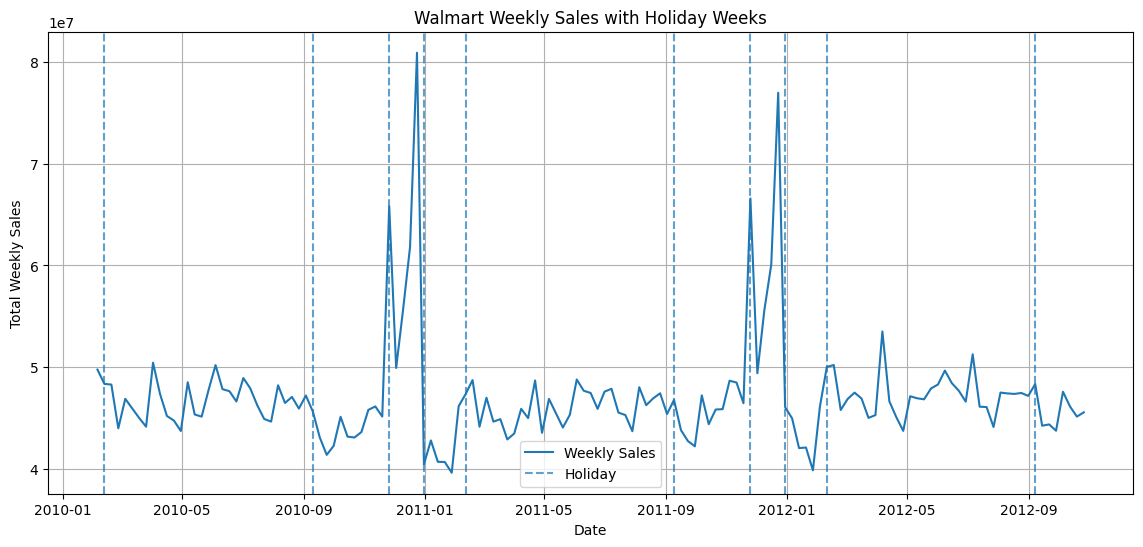

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# make sure date is datetime
df_sales["Date"] = pd.to_datetime(df_sales["Date"])

# aggregate weekly sales
sales_by_date = (
    df_sales.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

# get holiday dates
holiday_dates = (
    df_sales[df_sales["IsHoliday"]]
    ["Date"]
    .drop_duplicates()
)

plt.figure(figsize=(14, 6))

# sales line
plt.plot(
    sales_by_date["Date"],
    sales_by_date["Weekly_Sales"],
    label="Weekly Sales"
)

# mark holidays
for date in holiday_dates:
    plt.axvline(
        date,
        linestyle="--",
        alpha=0.7,
        label="Holiday" if date == holiday_dates.iloc[0] else ""
    )

plt.title("Walmart Weekly Sales with Holiday Weeks")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()

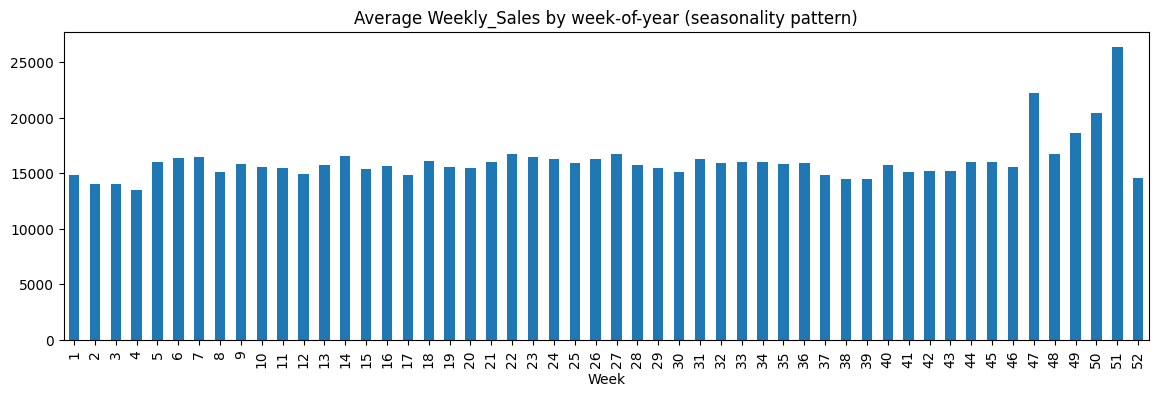

In [32]:
df_sales["Week"] = df_sales["Date"].dt.isocalendar().week
df_sales["Month"] = df_sales["Date"].dt.month
df_sales["Year"] = df_sales["Date"].dt.year

week_seasonality = df_sales.groupby("Week")["Weekly_Sales"].mean()
fig, ax = plt.subplots(figsize=(14, 4))
week_seasonality.plot(kind="bar", ax=ax)
ax.set_title("Average Weekly_Sales by week-of-year (seasonality pattern)")
plt.show()

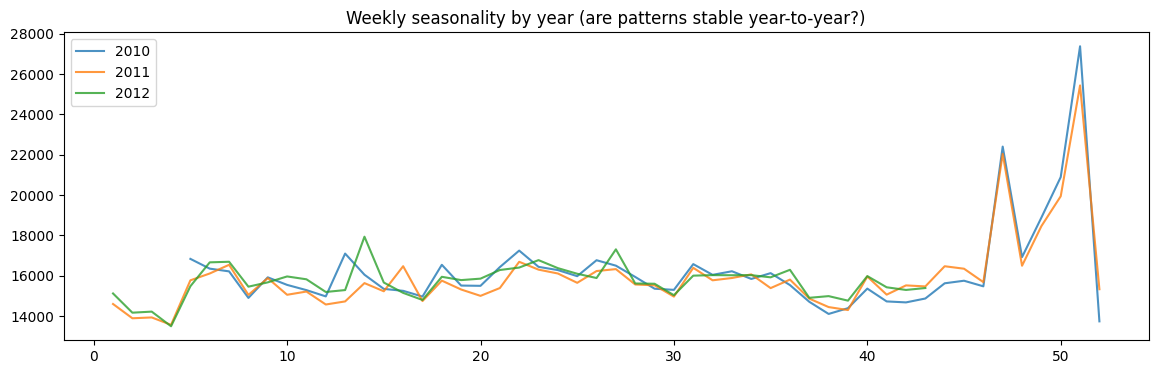

In [33]:
fig, ax = plt.subplots(figsize=(14, 4))
for yr, sub in df_sales.groupby("Year"):
    yearly = sub.groupby("Week")["Weekly_Sales"].mean()
    ax.plot(yearly.index, yearly.values, label=str(yr), alpha=0.8)
ax.legend()
ax.set_title("Weekly seasonality by year (are patterns stable year-to-year?)")
plt.show()

series length analysis

Series length distribution:
count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: count, dtype: float64

Series with <90% coverage: 560 / 3331


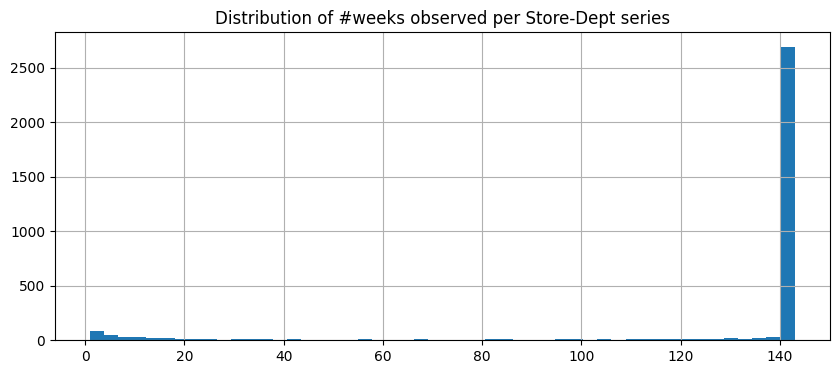

In [35]:
series_lengths = df_sales.groupby(["Store", "Dept"])["Date"].agg(["count", "min", "max"])
full_range_weeks = (df_sales["Date"].max() - df_sales["Date"].min()).days // 7 + 1
series_lengths["coverage_pct"] = series_lengths["count"] / full_range_weeks * 100

print("Series length distribution:")
print(series_lengths["count"].describe())
print(f"\nSeries with <90% coverage: {(series_lengths['coverage_pct'] < 90).sum()} / {len(series_lengths)}")

fig, ax = plt.subplots(figsize=(10, 4))
series_lengths["count"].hist(bins=50, ax=ax)
ax.set_title("Distribution of #weeks observed per Store-Dept series")
plt.show()

Keeping 2906 / 3331 series (length >= 87)
Aggregate (long series only) length: 143
Using 52 lags


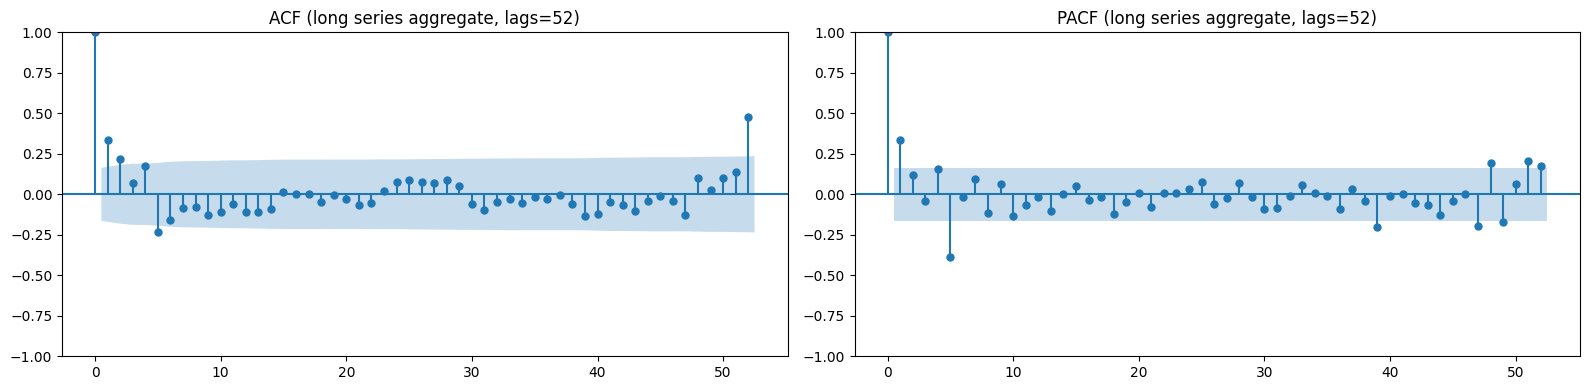

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 1. Filter to long series first ---
series_lengths = df_sales.groupby(["Store", "Dept"], observed=True)["Weekly_Sales"].count()

MIN_LEN = 52 + 35
long_series_ids = series_lengths[series_lengths >= MIN_LEN].index
print(f"Keeping {len(long_series_ids)} / {len(series_lengths)} series (length >= {MIN_LEN})")

df_long = df_sales.set_index(["Store", "Dept"]).loc[long_series_ids].reset_index()
df_long["Date"] = pd.to_datetime(df_long["Date"])


agg_long = df_long.groupby("Date")["Weekly_Sales"].sum()
agg_long_weekly = agg_long.asfreq("W-FRI").interpolate()

n = len(agg_long_weekly.dropna())
print(f"Aggregate (long series only) length: {n}")
max_lags = min(52, n // 2 - 1)
print(f"Using {max_lags} lags")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(agg_long_weekly.dropna(), lags=max_lags, ax=axes[0])
axes[0].set_title(f"ACF (long series aggregate, lags={max_lags})")
plot_pacf(agg_long_weekly.dropna(), lags=max_lags, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF (long series aggregate, lags={max_lags})")
plt.tight_layout()
plt.show()


Holiday/Sales correlation

In [43]:
holiday_stats = df_sales.groupby("IsHoliday")["Weekly_Sales"].agg(
    ["mean", "median", "std", "count"]
)
print(holiday_stats)
print(f"\nMean lift (holiday / non-holiday): "
      f"{holiday_stats.loc[True, 'mean'] / holiday_stats.loc[False, 'mean']:.2f}x")


                   mean   median           std   count
IsHoliday                                             
False      15901.445069  7589.95  22330.747450  391909
True       17035.823187  7947.74  27222.000409   29661

Mean lift (holiday / non-holiday): 1.07x


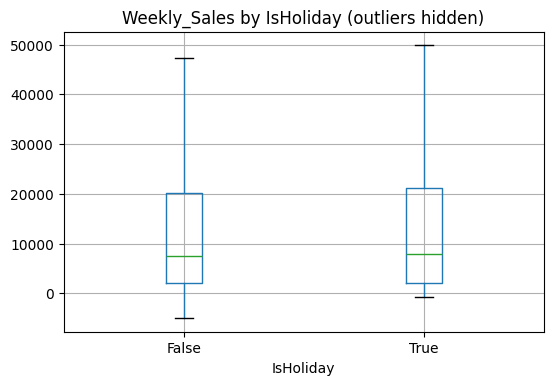

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
df_sales.boxplot(column="Weekly_Sales", by="IsHoliday", ax=ax, showfliers=False)
ax.set_title("Weekly_Sales by IsHoliday (outliers hidden)")
plt.suptitle("")
plt.show()

Breaking down dependency of sales with # of weeks before holiday

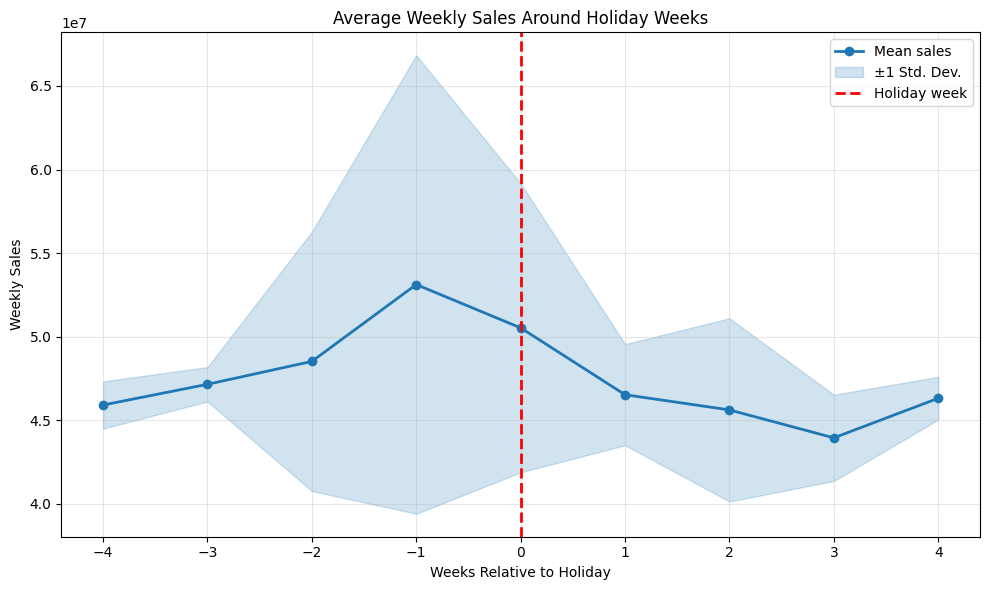

In [76]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary.index,
    summary["mean"],
    marker="o",
    linewidth=2,
    color="C0",
    label="Mean sales"
)

plt.fill_between(
    summary.index,
    summary["lower"],
    summary["upper"],
    color="C0",
    alpha=0.2,
    label="±1 Std. Dev."
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Holiday week"
)

plt.xticks(summary.index.astype(int))
plt.xlabel("Weeks Relative to Holiday")
plt.ylabel("Weekly Sales")
plt.title("Average Weekly Sales Around Holiday Weeks")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

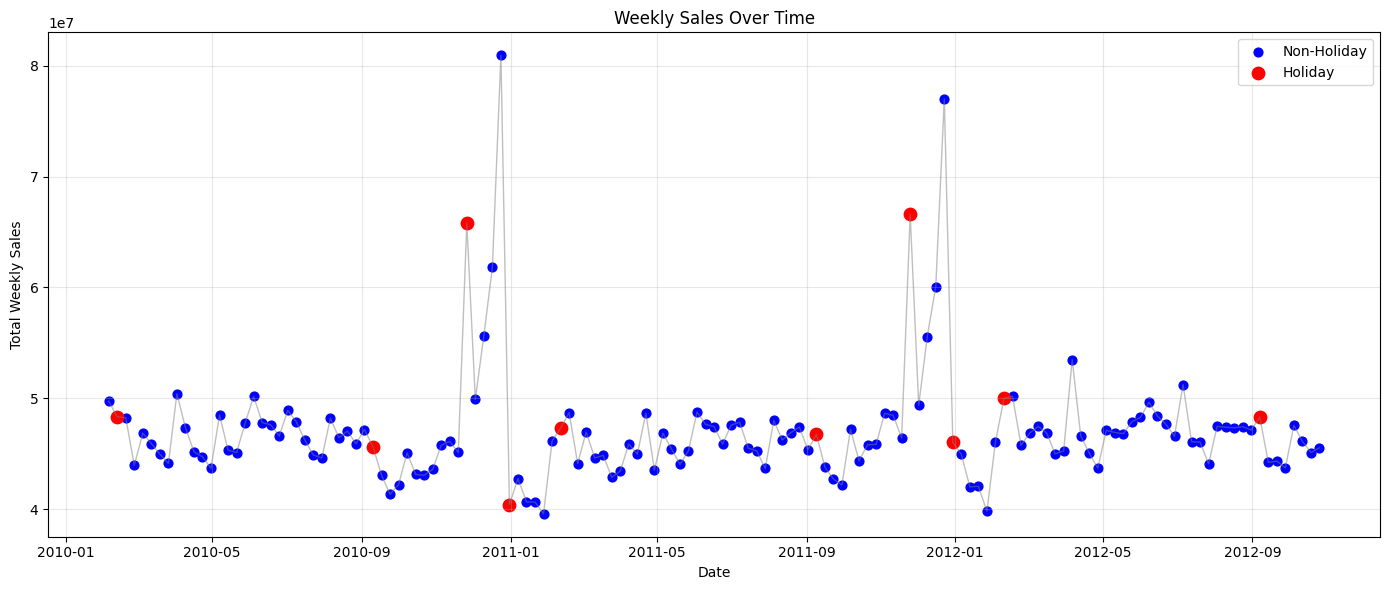

In [78]:
import matplotlib.pyplot as plt

# Aggregate sales by week
weekly = (
    df_sales.groupby("Date", as_index=False)
    .agg(
        Weekly_Sales=("Weekly_Sales", "sum"),
        IsHoliday=("IsHoliday", "max")
    )
    .sort_values("Date")
)

plt.figure(figsize=(14, 6))

# Non-holiday weeks (blue)
non_holiday = weekly[~weekly["IsHoliday"]]
plt.scatter(
    non_holiday["Date"],
    non_holiday["Weekly_Sales"],
    color="blue",
    s=40,
    label="Non-Holiday"
)

# Holiday weeks (red)
holiday = weekly[weekly["IsHoliday"]]
plt.scatter(
    holiday["Date"],
    holiday["Weekly_Sales"],
    color="red",
    s=80,
    label="Holiday"
)

# Connect points to show trend
plt.plot(
    weekly["Date"],
    weekly["Weekly_Sales"],
    color="gray",
    alpha=0.5,
    linewidth=1
)

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

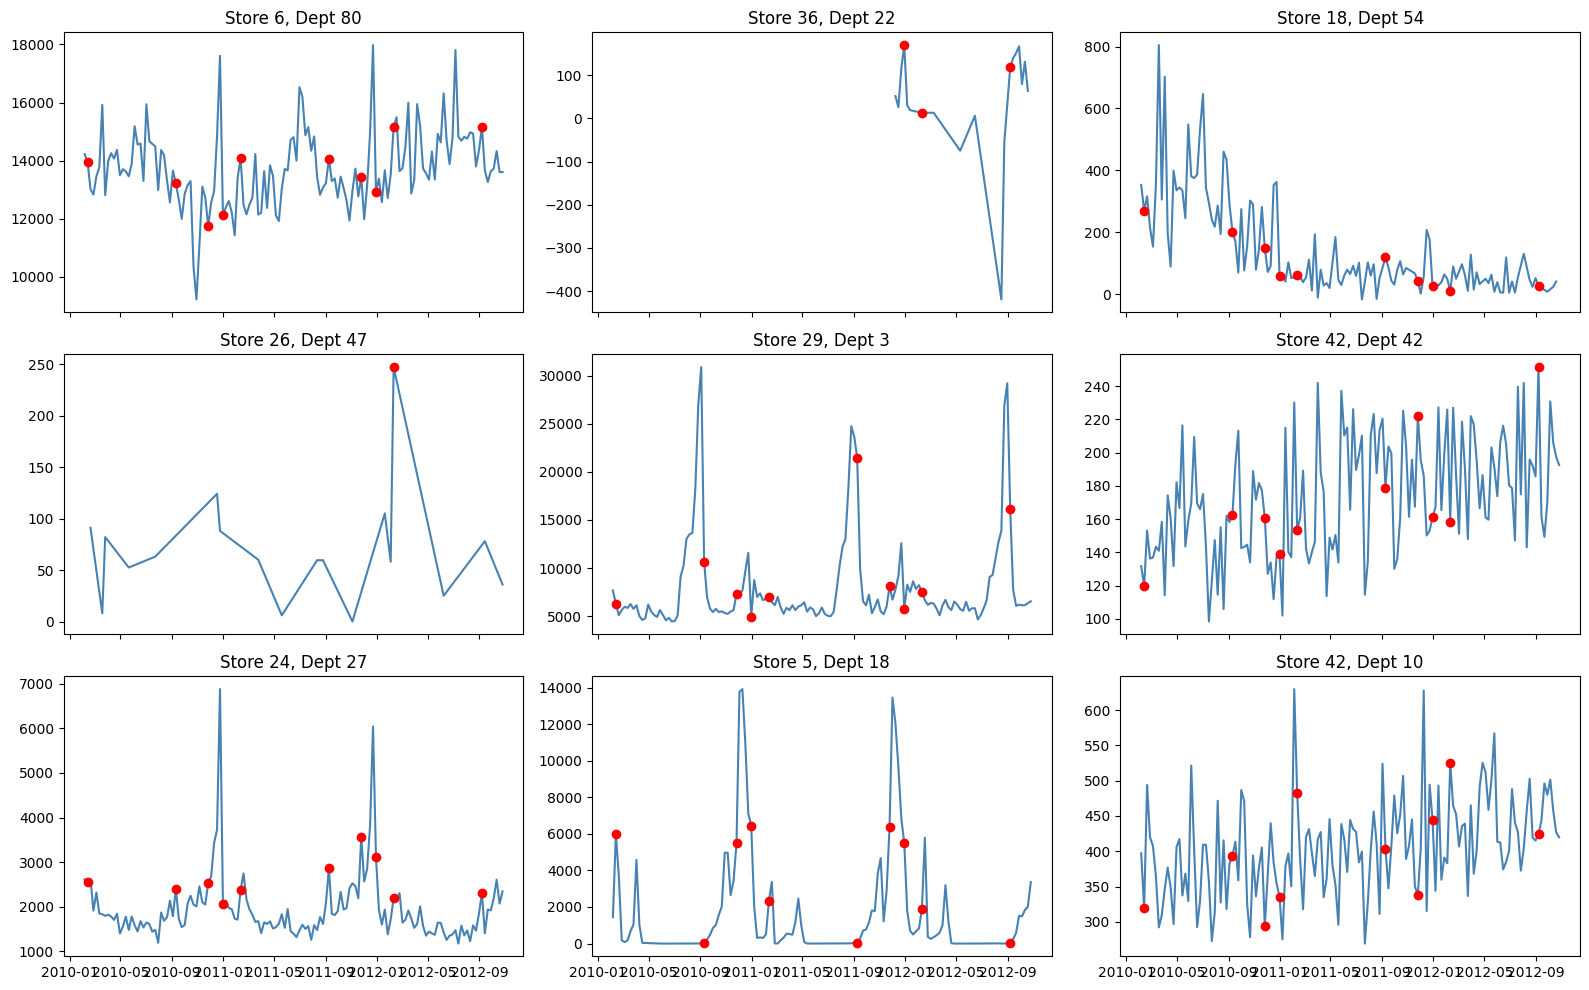

In [81]:
import numpy as np
import matplotlib.pyplot as plt

series = (
    df_sales[["Store", "Dept"]]
    .drop_duplicates()
    .sample(9, random_state=42)
)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)

for ax, (_, row) in zip(axes.ravel(), series.iterrows()):
    s = df_sales[
        (df_sales["Store"] == row.Store) &
        (df_sales["Dept"] == row.Dept)
    ].sort_values("Date")

    ax.plot(s["Date"], s["Weekly_Sales"], color="steelblue")

    holidays = s[s["IsHoliday"]]
    ax.scatter(
        holidays["Date"],
        holidays["Weekly_Sales"],
        color="red",
        zorder=3
    )

    ax.set_title(f"Store {row.Store}, Dept {row.Dept}")

plt.tight_layout()
plt.show()

**Analyzing Features**

In [57]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [58]:
df_features["Date"] = pd.to_datetime(df_features["Date"])

print(df_features["Date"].min())
print(df_features["Date"].max())

print(df_features["Date"].nunique())

2010-02-05 00:00:00
2013-07-26 00:00:00
182


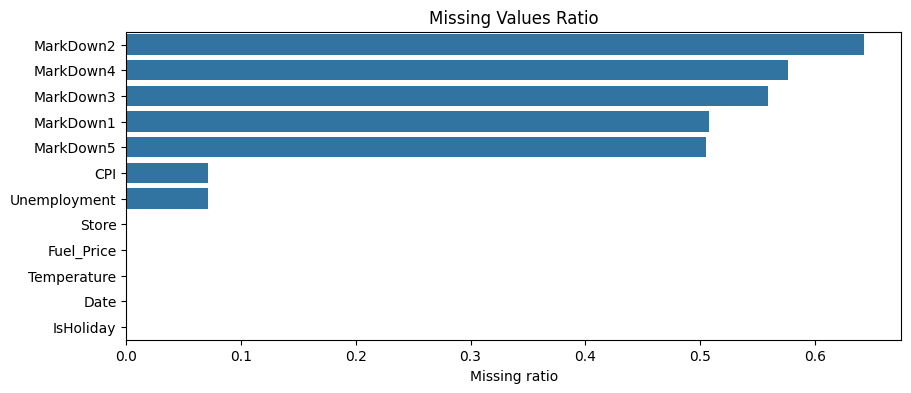

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_features["Date"] = pd.to_datetime(df_features["Date"])

plt.figure(figsize=(10,4))

missing = df_features.isna().mean().sort_values(ascending=False)

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values Ratio")
plt.xlabel("Missing ratio")
plt.ylabel("")
plt.show()


Numeric Columsn Analyze

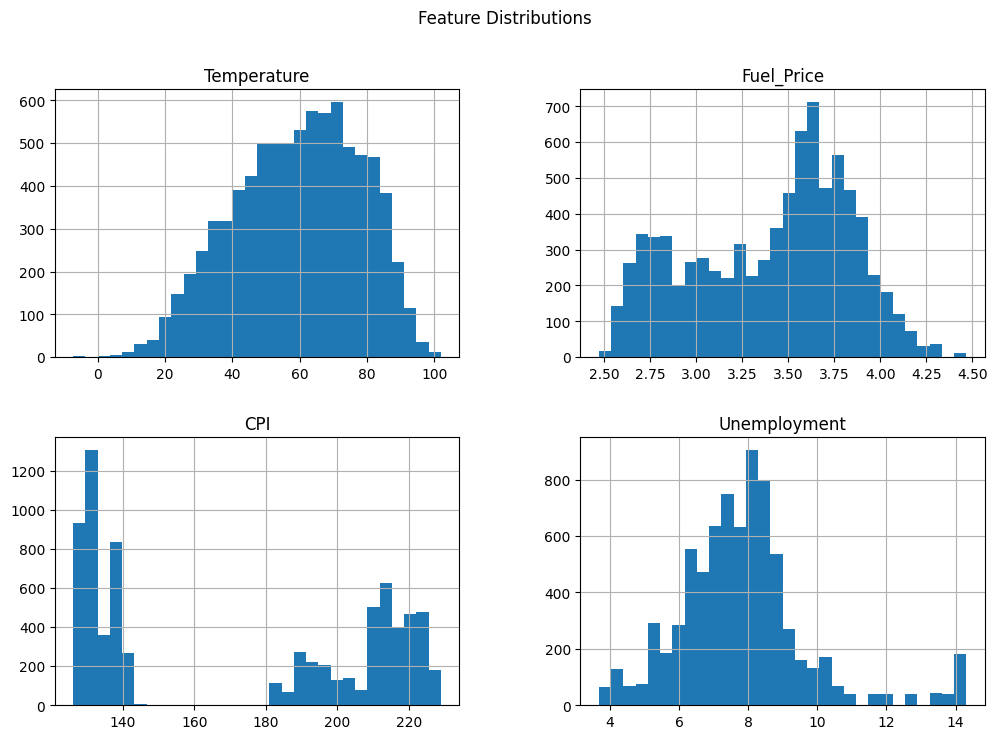

In [61]:
numeric_cols = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

df_features[numeric_cols].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Feature Distributions")
plt.show()

Time Trends

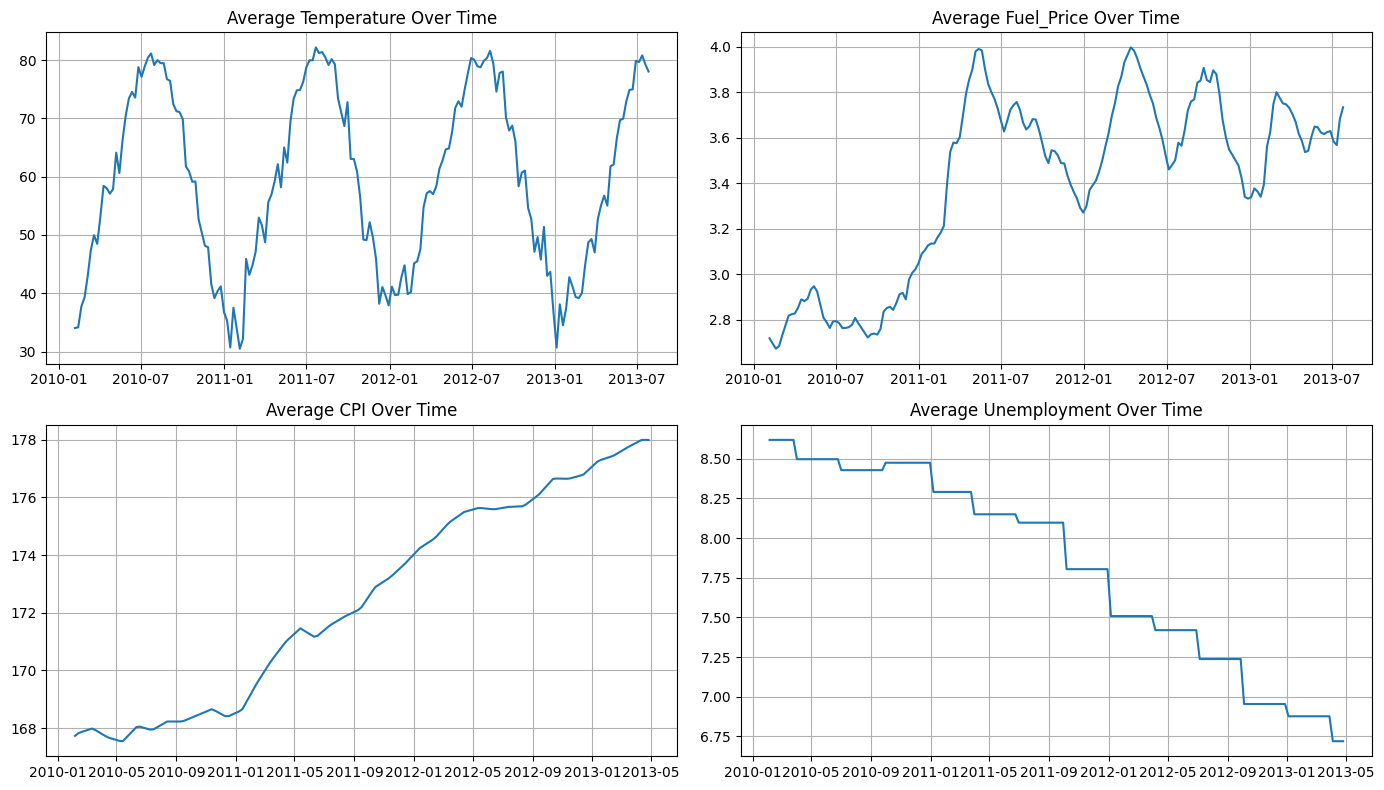

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

for col, ax in zip(numeric_cols, axes.flatten()):

    trend = (
        df_features
        .groupby("Date")[col]
        .mean()
    )

    ax.plot(trend.index, trend.values)
    ax.set_title(f"Average {col} Over Time")
    ax.grid(True)

plt.tight_layout()
plt.show()


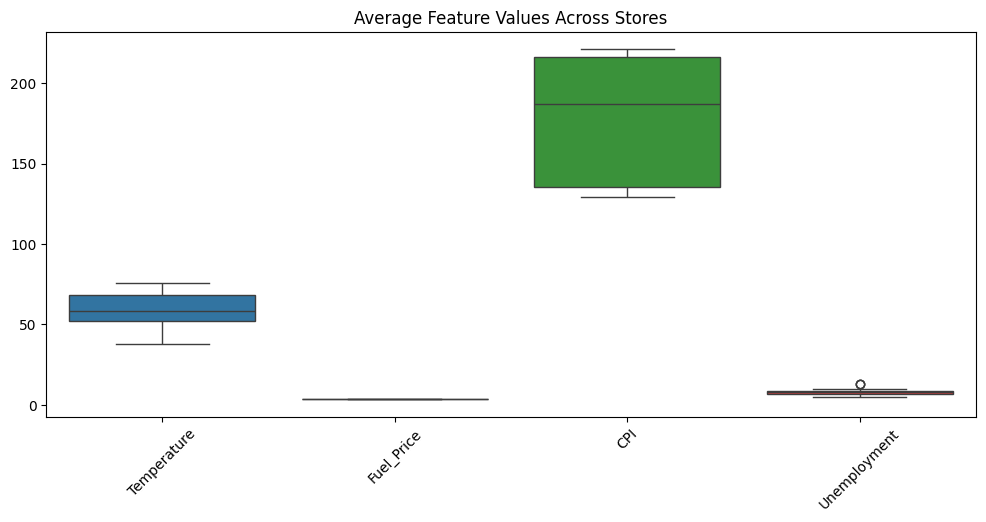

In [63]:
store_stats = (
    df_features
    .groupby("Store")[[
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment"
    ]]
    .mean()
)


plt.figure(figsize=(12,5))

sns.boxplot(
    data=store_stats
)

plt.title("Average Feature Values Across Stores")
plt.xticks(rotation=45)

plt.show()


**Full Dataset**

In [64]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [65]:
df_sales["Date"] = pd.to_datetime(df_sales["Date"])
df_features["Date"] = pd.to_datetime(df_features["Date"])

# merge sales with features
df = df_sales.merge(
    df_features,
    on=["Store", "Date"],
    how="left"
)

# merge store information
df = df.merge(
    df_stores,
    on="Store",
    how="left"
)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Week,Month,Year,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,5,2,2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,6,2,2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,7,2,2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,8,2,2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,9,3,2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


Department Behaviour

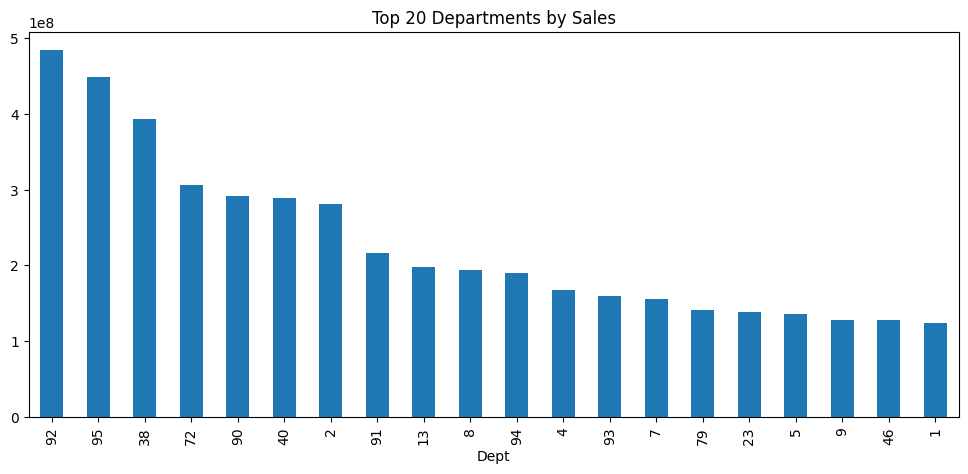

In [66]:
dept_sales = (
    df.groupby("Dept")
    ["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12,5))

dept_sales.head(20).plot(
    kind="bar"
)

plt.title("Top 20 Departments by Sales")

plt.show()

Stores Behaviour

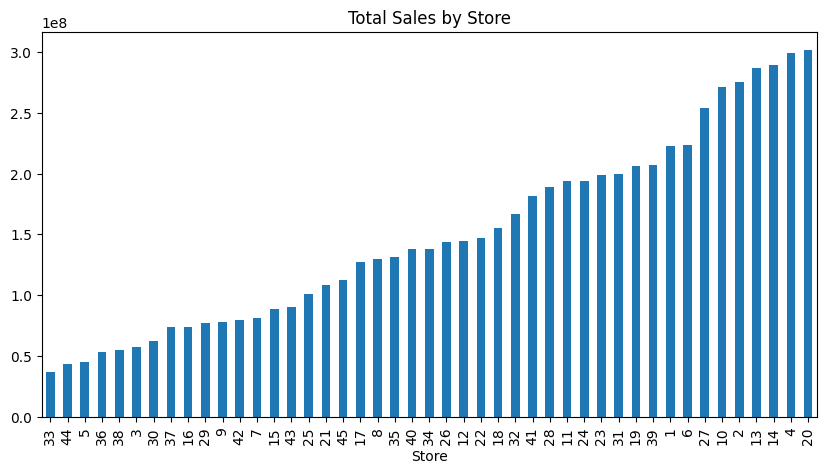

In [67]:
store_sales = (
    df.groupby("Store")
    ["Weekly_Sales"]
    .sum()
    .sort_values()
)


plt.figure(figsize=(10,5))

store_sales.plot(
    kind="bar"
)

plt.title("Total Sales by Store")

plt.show()

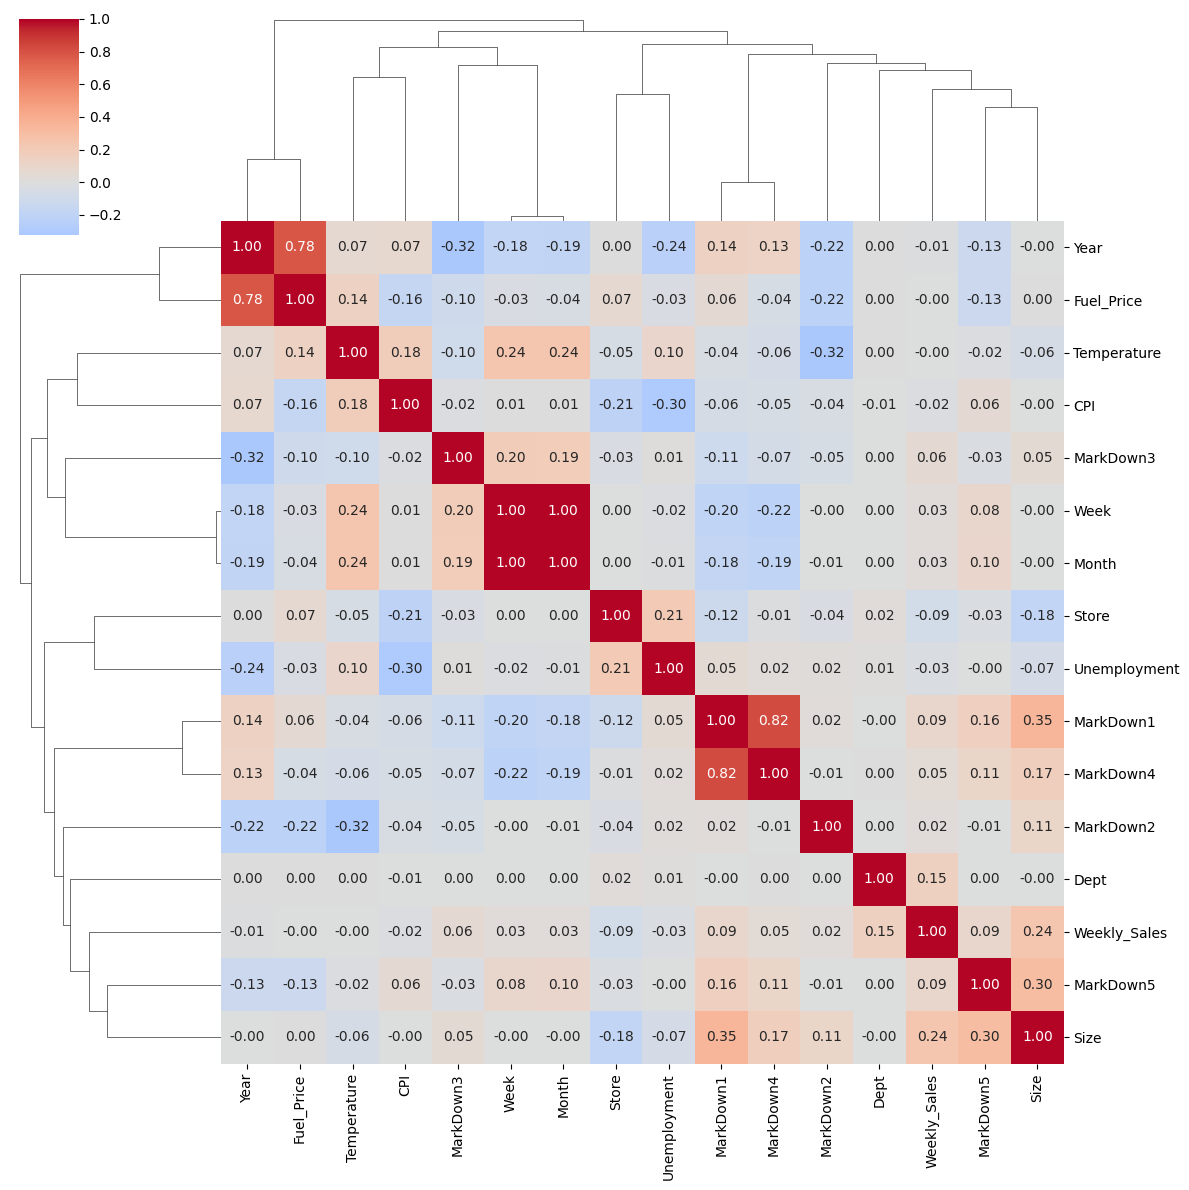

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = df.select_dtypes(include="number")

corr = numeric.corr()

sns.clustermap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    figsize=(12, 12)
)

plt.show()

**Saving**

In [82]:
df_sales.to_csv("/content/drive/MyDrive/WalmartPrices/sales.csv")
df_stores.to_csv("/content/drive/MyDrive/WalmartPrices/stores.csv")
df_features.to_csv("/content/drive/MyDrive/WalmartPrices/features.csv")
df.to_csv("/content/drive/MyDrive/WalmartPrices/full.csv")